In [ ]:
!pip install ijson==3.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import ijson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [ ]:
def load_files_to_dfs(folder_path):
    # List to store the dataframes
    honda_dfs = []

    # Get all folders (assuming they are numbered and in the folder_path)
    for folder in os.listdir(folder_path):
        folder_num = folder  # Folder name (assuming it is the number)
        folder_full_path = os.path.join(folder_path, folder)

        if os.path.isdir(folder_full_path):
            # Look specifically for the 'insoles.csv' and 'labels.csv' file in each folder
            file_path_insoles = os.path.join(folder_full_path, 'insoles.csv')
            file_path_labels = os.path.join(folder_full_path, 'labels.csv')

            # making sure both paths exist prior to uploading df
            if os.path.exists(file_path_insoles):
                if os.path.exists(file_path_labels):
                    # Load the files into a DataFrames (assuming csv format)
                    df_insoles = pd.read_csv(file_path_insoles)
                    df_labels = pd.read_csv(file_path_labels)

                    # Merge the two DataFrames on the 'time', 'participant_id', 'task' column
                    df = pd.merge(df_insoles, df_labels, on=['time', 'participant_id', 'task'])

                    # Add participant_num column
                    df['participant_num'] = folder_num
                    print(folder_num)

                    # Add the DataFrame to the list
                    honda_dfs.append(df)

    return honda_dfs

# Usage example
folder_path = '/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/data_set/courseA'  # Replace with the path to the main directory containing folders
dataframes = load_files_to_dfs(folder_path)

# # Print the dataframes list
# for idx, df in enumerate(dataframes):
#     print(f"DataFrame from folder {idx + 1}:\n", df.head())


id08
id22
id23
id07
id14
id12
id24
id25
id15
id01
id16
id13
id05
id03
id19
id17
id10
id04
id02
id18


In [ ]:
len(dataframes)

20

In [ ]:
dataframes_copy = dataframes

In [ ]:
#list all the columns
# list(dataframes[0].columns)

In [ ]:
dataframes[0]['walk_mode'].unique()

array(['walk', 'stairs_down', 'stairs_up', 'slope_down', 'slope_up'],
      dtype=object)

In [ ]:
dataframes[0]

,Unnamed: 0,time,participant_id,task,Left_Hallux,Left_Toes,Left_Met1,Left_Met3,Left_Met5,Left_Arch,...,insoles_RightFoot_time_to_lift,xsens_footContacts_LeftFoot_Heel,xsens_footContacts_LeftFoot_Toe,xsens_footContacts_RightFoot_Heel,xsens_footContacts_RightFoot_Toe,walk_orientation,walk_interaction,walk_mode_id,walk_orientation_id,participant_num
0,0,0,8,A,179.0,6.0,2.0,229.0,337.0,366.0,...,767.0,False,False,True,False,straight,no,1,1,id08
1,1,17,8,A,177.0,3.0,4.0,231.0,341.0,359.0,...,750.0,False,False,True,False,straight,no,1,1,id08
2,2,34,8,A,175.0,0.0,3.0,235.0,337.0,366.0,...,733.0,False,True,True,False,straight,no,1,1,id08
3,3,50,8,A,179.0,0.0,1.0,234.0,338.0,360.0,...,717.0,False,False,True,False,straight,no,1,1,id08
4,4,67,8,A,181.0,3.0,0.0,235.0,338.0,361.0,...,700.0,False,False,True,False,straight,no,1,1,id08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43356,43356,722600,8,A,2.0,0.0,0.0,1.0,1.0,2.0,...,-1.0,False,False,False,False,straight,no,16,5,id08
43357,43357,722617,8,A,1.0,2.0,4.0,1.0,0.0,1.0,...,-1.0,False,False,False,False,straight,no,16,5,id08
43358,43358,722634,8,A,3.0,1.0,0.0,0.0,3.0,1.0,...,-1.0,False,False,False,False,straight,no,16,5,id08
43359,43359,722650,8,A,1.0,1.0,3.0,1.0,4.0,1.0,...,-1.0,False,False,False,False,straight,no,16,5,id08


In [ ]:
sensor_types = ['Acc','Mag','Gyr']

leg = ['Left', 'Right']

sensor_locations = ['Hallux', 'Toes', 'Met1', 'Met3', 'Met5', 'Arch', 'Heel_R', 'Heel_L']

axes = ['x', 'y', 'z', 'raw', 'norm']

columns = ['Unnamed: 0', 'time', 'participant_id', 'task', 'Left_Hallux', 'Left_Toes', 'Left_Met1',
           'Left_Met3', 'Left_Met5', 'Left_Arch', 'Left_Heel_R', 'Left_Heel_L', 'Left_Acc_x', 'Left_Acc_y', 'Left_Acc_z',
           'Left_Gyr_x', 'Left_Gyr_y', 'Left_Gyr_z', 'Left_Mag_x', 'Left_Mag_y', 'Left_Mag_z', 'Left_Temp', 'Right_Hallux',
           'Right_Toes', 'Right_Met1', 'Right_Met3', 'Right_Met5', 'Right_Arch', 'Right_Heel_L', 'Right_Heel_R', 'Right_Acc_x',
           'Right_Acc_y', 'Right_Acc_z', 'Right_Gyr_x', 'Right_Gyr_y', 'Right_Gyr_z', 'Right_Mag_x', 'Right_Mag_y', 'Right_Mag_z',
           'Right_Temp', 'Right_Toes_raw', 'Right_Hallux_raw', 'Right_Met5_raw', 'Right_Met3_raw', 'Right_Met1_raw', 'Right_Arch_raw', 'Right_Heel_R_raw',
           'Right_Heel_L_raw', 'Left_Toes_raw', 'Left_Hallux_raw', 'Left_Met5_raw', 'Left_Met3_raw', 'Left_Met1_raw', 'Left_Arch_raw', 'Left_Heel_R_raw',
           'Left_Heel_L_raw', 'Right_Acc_x_raw', 'Right_Acc_y_raw', 'Right_Acc_z_raw', 'Right_Mag_x_raw', 'Right_Mag_y_raw', 'Right_Mag_z_raw', 'Right_Gyr_x_raw',
           'Right_Gyr_y_raw', 'Right_Gyr_z_raw', 'Left_Acc_x_raw', 'Left_Acc_y_raw', 'Left_Acc_z_raw', 'Left_Mag_x_raw', 'Left_Mag_z_raw', 'Left_Gyr_x_raw',
           'Left_Gyr_y_raw', 'Left_Gyr_z_raw', 'Left_Hallux_norm', 'Left_Toes_norm', 'Left_Met1_norm', 'Left_Met3_norm', 'Left_Met5_norm', 'Left_Arch_norm',
           'Left_Heel_R_norm', 'Left_Heel_L_norm', 'Right_Hallux_norm', 'Right_Toes_norm', 'Right_Met1_norm', 'Right_Met3_norm', 'Right_Met5_norm', 'Right_Arch_norm',
           'Right_Heel_L_norm', 'Right_Heel_R_norm', 'Left_Max_Pressure_norm', 'Right_Max_Pressure_norm', 'walk_mode', 'repetition', 'insoles_RightFoot_is_step',
           'insoles_LeftFoot_is_step', 'insoles_RightFoot_is_lifted', 'insoles_LeftFoot_is_lifted', 'insoles_LeftFoot_on_ground',
           'insoles_RightFoot_on_ground', 'insoles_LeftFoot_time_to_step', 'insoles_LeftFoot_time_to_lift', 'insoles_RightFoot_time_to_step',
           'insoles_RightFoot_time_to_lift', 'xsens_footContacts_LeftFoot_Heel', 'xsens_footContacts_LeftFoot_Toe', 'xsens_footContacts_RightFoot_Heel',
           'xsens_footContacts_RightFoot_Toe', 'walk_orientation', 'walk_interaction', 'walk_mode_id', 'walk_orientation_id', 'participant_num']


In [ ]:
# get the 5 types of surfaces/actions done in this dataset
walk_modes = dataframes_copy[0]['walk_mode'].unique()

# create a subset dataframe for each of the types
subset_dfs = {}
for walk_mode in walk_modes:
  for df in dataframes_copy:
      identifier = walk_mode + '_' + df['participant_num'].iloc[0]
      if identifier not in subset_dfs:
          subset_dfs[identifier] = df[df['walk_mode'] == walk_mode]


In [ ]:
# change the column names wiht no suffix to have

In [ ]:
# subset_dfs['slope_up_id12']

In [ ]:
extras_df = []

for key, df in subset_dfs.items():
    df.columns = columns
    # keep only listed columns
    df = df[['Unnamed: 0', 'time', 'participant_id', 'task','Left_Max_Pressure_norm', 'Right_Max_Pressure_norm', 'walk_mode', 'repetition', 'insoles_RightFoot_is_step',
           'insoles_LeftFoot_is_step', 'insoles_RightFoot_is_lifted', 'insoles_LeftFoot_is_lifted', 'insoles_LeftFoot_on_ground',
           'insoles_RightFoot_on_ground', 'insoles_LeftFoot_time_to_step', 'insoles_LeftFoot_time_to_lift', 'insoles_RightFoot_time_to_step',
           'insoles_RightFoot_time_to_lift', 'xsens_footContacts_LeftFoot_Heel', 'xsens_footContacts_LeftFoot_Toe', 'xsens_footContacts_RightFoot_Heel',
           'xsens_footContacts_RightFoot_Toe', 'walk_orientation', 'walk_interaction']]

    extras_df.append(df)

# Concatenate all trials into a single DataFrame
all_foot_sensor_extras_df = pd.concat(extras_df, ignore_index=True)

In [ ]:
all_foot_sensor_extras_df

,Unnamed: 0,time,participant_id,task,Left_Max_Pressure_norm,Right_Max_Pressure_norm,walk_mode,repetition,insoles_RightFoot_is_step,insoles_LeftFoot_is_step,...,insoles_LeftFoot_time_to_step,insoles_LeftFoot_time_to_lift,insoles_RightFoot_time_to_step,insoles_RightFoot_time_to_lift,xsens_footContacts_LeftFoot_Heel,xsens_footContacts_LeftFoot_Toe,xsens_footContacts_RightFoot_Heel,xsens_footContacts_RightFoot_Toe,walk_orientation,walk_interaction
0,0,0,8,A,0.906009,0.380305,walk,1,True,True,...,0.0,217.0,0.0,767.0,False,False,True,False,straight,no
1,1,17,8,A,0.911848,0.448660,walk,1,False,False,...,667.0,200.0,1217.0,750.0,False,False,True,False,straight,no
2,2,34,8,A,0.906569,0.473807,walk,1,False,False,...,650.0,183.0,1200.0,733.0,False,True,True,False,straight,no
3,3,50,8,A,0.934059,0.504003,walk,1,False,False,...,634.0,167.0,1184.0,717.0,False,False,True,False,straight,no
4,4,67,8,A,0.955711,0.516030,walk,1,False,False,...,617.0,150.0,1167.0,700.0,False,False,True,False,straight,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846710,45502,758366,18,A,1.000000,0.002514,slope_up,3,False,False,...,600.0,134.0,84.0,750.0,False,False,False,False,straight,no
846711,45503,758383,18,A,1.000000,0.001969,slope_up,3,False,False,...,583.0,117.0,67.0,733.0,False,False,True,False,straight,no
846712,45504,758400,18,A,1.000000,0.001572,slope_up,3,False,False,...,566.0,100.0,50.0,716.0,False,False,True,False,straight,no
846713,45505,758416,18,A,1.000000,0.003207,slope_up,3,False,False,...,550.0,84.0,34.0,700.0,False,True,True,False,straight,no


In [ ]:
import pandas as pd

# Define your list of sensor locations
sensor_locations = ['Hallux', 'Toes', 'Met1', 'Met3', 'Met5', 'Arch', 'Heel_R', 'Heel_L']

# Function to extract the sensor location from a column name based on the sensor_locations list
def extract_sensor_location(column_name):
    for location in sensor_locations:
        if location in column_name:
            return location
    return None

# Function to remove the sensor location from a column name
def remove_sensor_location(column_name):
    for location in sensor_locations:
        if location in column_name:
            return column_name.replace(location, '').strip('_')
    return column_name

# Initialize a list to hold DataFrames for all trials
all_trials_df_list = []

# Loop over each DataFrame in subset_dfs (assuming it's a dictionary of trial DataFrames)
for key, trial_df in subset_dfs.items():
    df_list = []
    surface_type = key.split('_')
    if len(surface_type) > 2:
        surface_type = ' '.join(surface_type[:2])
    else:
        surface_type = surface_type[0]

    # For each sensor, collect relevant columns and create a new DataFrame
    for sensor_location in sensor_locations:
        # Find all columns related to this sensor location
        sensor_columns = [col for col in trial_df.columns if sensor_location in col]

        if sensor_columns:
            # Create a new DataFrame for this sensor
            df_by_sensor = pd.DataFrame({
                "time": trial_df["time"],
                "participant_id": trial_df["participant_id"],
                "task": trial_df["task"],
                "surface_type": surface_type,
                "sensor_location": sensor_location
            })

            # For each sensor-related column, add it to the new DataFrame
            for col in sensor_columns:
                new_column_name = remove_sensor_location(col)
                df_by_sensor[new_column_name] = trial_df[col]

            # Append the sensor DataFrame to the list
            df_list.append(df_by_sensor)

    # Concatenate all DataFrames for this trial and add to the main list if any were created
    if df_list:
        trial_df_combined = pd.concat(df_list)
        all_trials_df_list.append(trial_df_combined)

        print(f"Processed {key}")
    else:
        print(f"No valid sensor columns to process for {key}")

# Concatenate all trials into a single DataFrame
all_foot_sensors_df = pd.concat(all_trials_df_list, ignore_index=True)

# Uncomment to export the final combined DataFrame to CSV
# final_combined_df.to_csv('/path/to/final_output.csv', index=False)



Processed walk_id08
Processed walk_id22
Processed walk_id23
Processed walk_id07
Processed walk_id14
Processed walk_id12
Processed walk_id24
Processed walk_id25
Processed walk_id15
Processed walk_id01
Processed walk_id16
Processed walk_id13
Processed walk_id05
Processed walk_id03
Processed walk_id19
Processed walk_id17
Processed walk_id10
Processed walk_id04
Processed walk_id02
Processed walk_id18
Processed stairs_down_id08
Processed stairs_down_id22
Processed stairs_down_id23
Processed stairs_down_id07
Processed stairs_down_id14
Processed stairs_down_id12
Processed stairs_down_id24
Processed stairs_down_id25
Processed stairs_down_id15
Processed stairs_down_id01
Processed stairs_down_id16
Processed stairs_down_id13
Processed stairs_down_id05
Processed stairs_down_id03
Processed stairs_down_id19
Processed stairs_down_id17
Processed stairs_down_id10
Processed stairs_down_id04
Processed stairs_down_id02
Processed stairs_down_id18
Processed stairs_up_id08
Processed stairs_up_id22
Processed 

In [ ]:
all_foot_sensors_df

,time,participant_id,task,surface_type,sensor_location,Left,Right,Right__raw,Left__raw,Left__norm,Right__norm
0,0,8,A,walk,Hallux,179.0,3.0,4092.199622,3081.392632,0.720356,0.001446
1,17,8,A,walk,Hallux,177.0,3.0,4091.532746,2978.724811,0.830405,0.001982
2,34,8,A,walk,Hallux,175.0,6.0,4094.932935,2911.396411,0.906569,0.000054
3,50,8,A,walk,Hallux,179.0,1.0,4091.599496,2887.599496,0.934059,0.001928
4,67,8,A,walk,Hallux,181.0,0.0,4090.733942,2869.201826,0.955711,0.002623
...,...,...,...,...,...,...,...,...,...,...,...
6773715,758366,18,A,slope up,Heel_L,482.0,0.0,4093.506162,4095.000000,0.000000,0.000811
6773716,758383,18,A,slope up,Heel_L,464.0,3.0,4094.839305,4095.000000,0.000000,0.000087
6773717,758400,18,A,slope up,Heel_L,453.0,0.0,4093.000000,4092.172448,0.001302,0.001086
6773718,758416,18,A,slope up,Heel_L,448.0,1.0,4093.505590,4095.000000,0.000000,0.000811


In [ ]:
plot_8 = all_foot_sensors_df[all_foot_sensors_df['participant_id'] == 8].sort_values(by='time')

In [ ]:
# plot_8_Hallux = all_foot_sensors_df[all_foot_sensors_df['participant_id'] == 8] & all_foot_sensors_df[all_foot_sensors_df['sensor_location'] == 'Hallux']

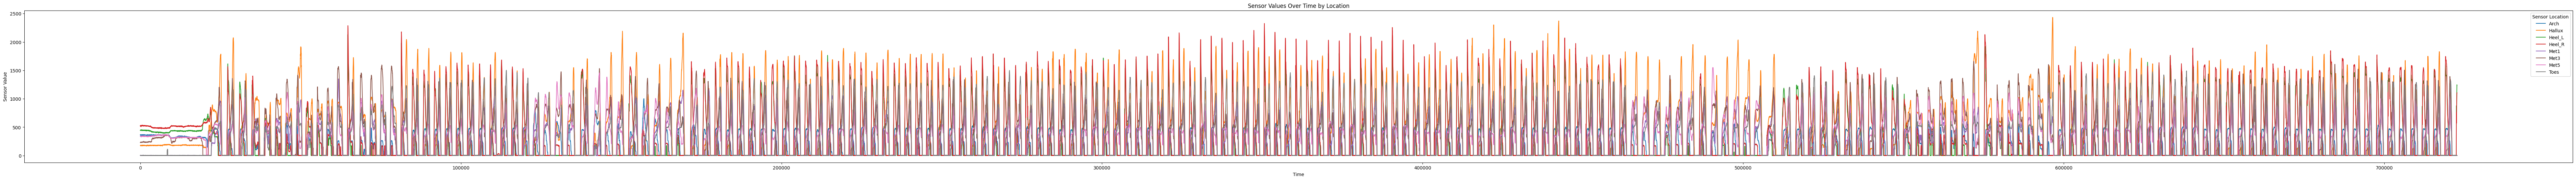

In [ ]:
import matplotlib.pyplot as plt

# Group by sensor location and plot each group separately
plt.figure(figsize=(100, 6))

for sensor_location, group_df in plot_8.groupby('sensor_location'):
    plt.plot(group_df['time'], group_df['Left'], label=sensor_location)

# Add labels, title, and legend
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.title('Sensor Values Over Time by Location')
plt.legend(title='Sensor Location')
plt.show()



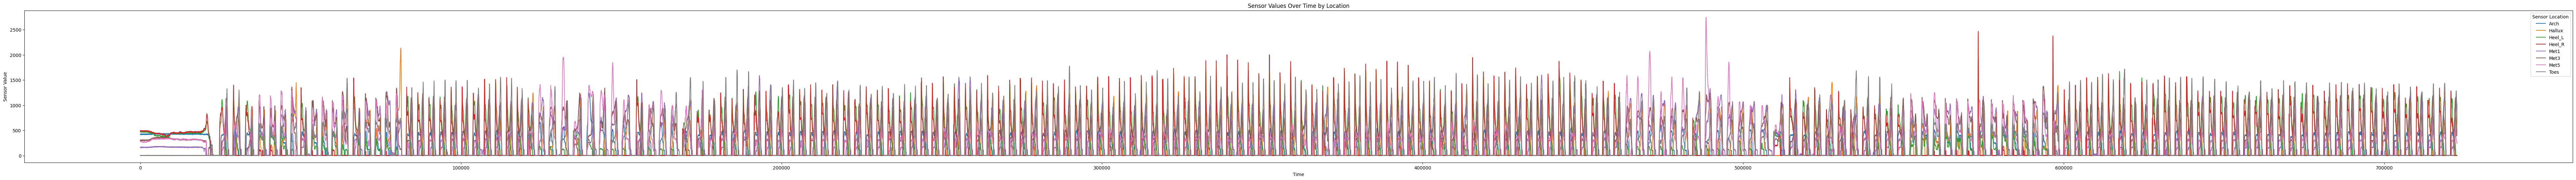

In [ ]:
import matplotlib.pyplot as plt

# Group by sensor location and plot each group separately
plt.figure(figsize=(100, 6))

for sensor_location, group_df in plot_8.groupby('sensor_location'):
    plt.plot(group_df['time'], group_df['Right'], label=sensor_location)

# Add labels, title, and legend
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.title('Sensor Values Over Time by Location')
plt.legend(title='Sensor Location')
plt.show()



In [ ]:
# export csv to folder
all_foot_sensors_df.to_csv('/content/drive/MyDrive/Next_Step/Honda_Participants/CourseA/foot_pressure_data/all_foot_sensors_df.csv', index=False)

In [ ]:
# export csv to folder
all_foot_sensor_extras_df.to_csv('/content/drive/MyDrive/Next_Step/Honda_Participants/CourseA/foot_pressure_data/all_foot_sensor_extras_df.csv', index=False)